# Jupyter 노트북 예제

이 노트북은 **`ai_env` 가상환경**이 올바르게 설정되었는지 점검합니다.  

✅ 체크 항목  
1. Python 3.10 및 PyTorch 2.7 버전  
2. GPU(CUDA 12.x) 인식 여부  
3. 간단한 행렬곱 연산 성능
4. Matplotlib 인라인 그래프 출력
5. TorchVision 사전학습 모델 추론

In [1]:
import sys, torch, numpy as np

print("AI 개발 환경!")
print("Python 버전 :", sys.version.split()[0])
print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능 여부 :", torch.cuda.is_available())
print("cuDNN 버전 :", torch.backends.cudnn.version())
if torch.cuda.is_available():
    print("GPU 이름      :", torch.cuda.get_device_name(0))

AI 개발 환경!
Python 버전 : 3.10.19
PyTorch 버전: 2.9.1+cu128
CUDA 사용 가능 여부 : True
cuDNN 버전 : 91002
GPU 이름      : NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
%%timeit -n 1 -r 3
# 대형 텐서 두 개를 GPU에서 행렬곱
x = torch.randn((4096, 4096), device="cuda")
y = torch.randn((4096, 4096), device="cuda") #device="cpu"로 바꾸면 CPU/GPU 차이 체감 가능
z = torch.matmul(x, y)
torch.cuda.synchronize()   # GPU 연산이 끝날 때까지 대기

The slowest run took 120.53 times longer than the fastest. This could mean that an intermediate result is being cached.
669 ms ± 922 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


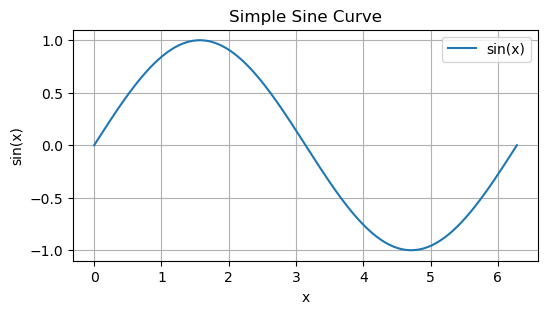

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# sin 곡선 0~2π
xs = np.linspace(0, 2*np.pi, 200)
ys = np.sin(xs)

plt.figure(figsize=(6,3))
plt.plot(xs, ys, label='sin(x)')
plt.title("Simple Sine Curve")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.legend()
plt.show()

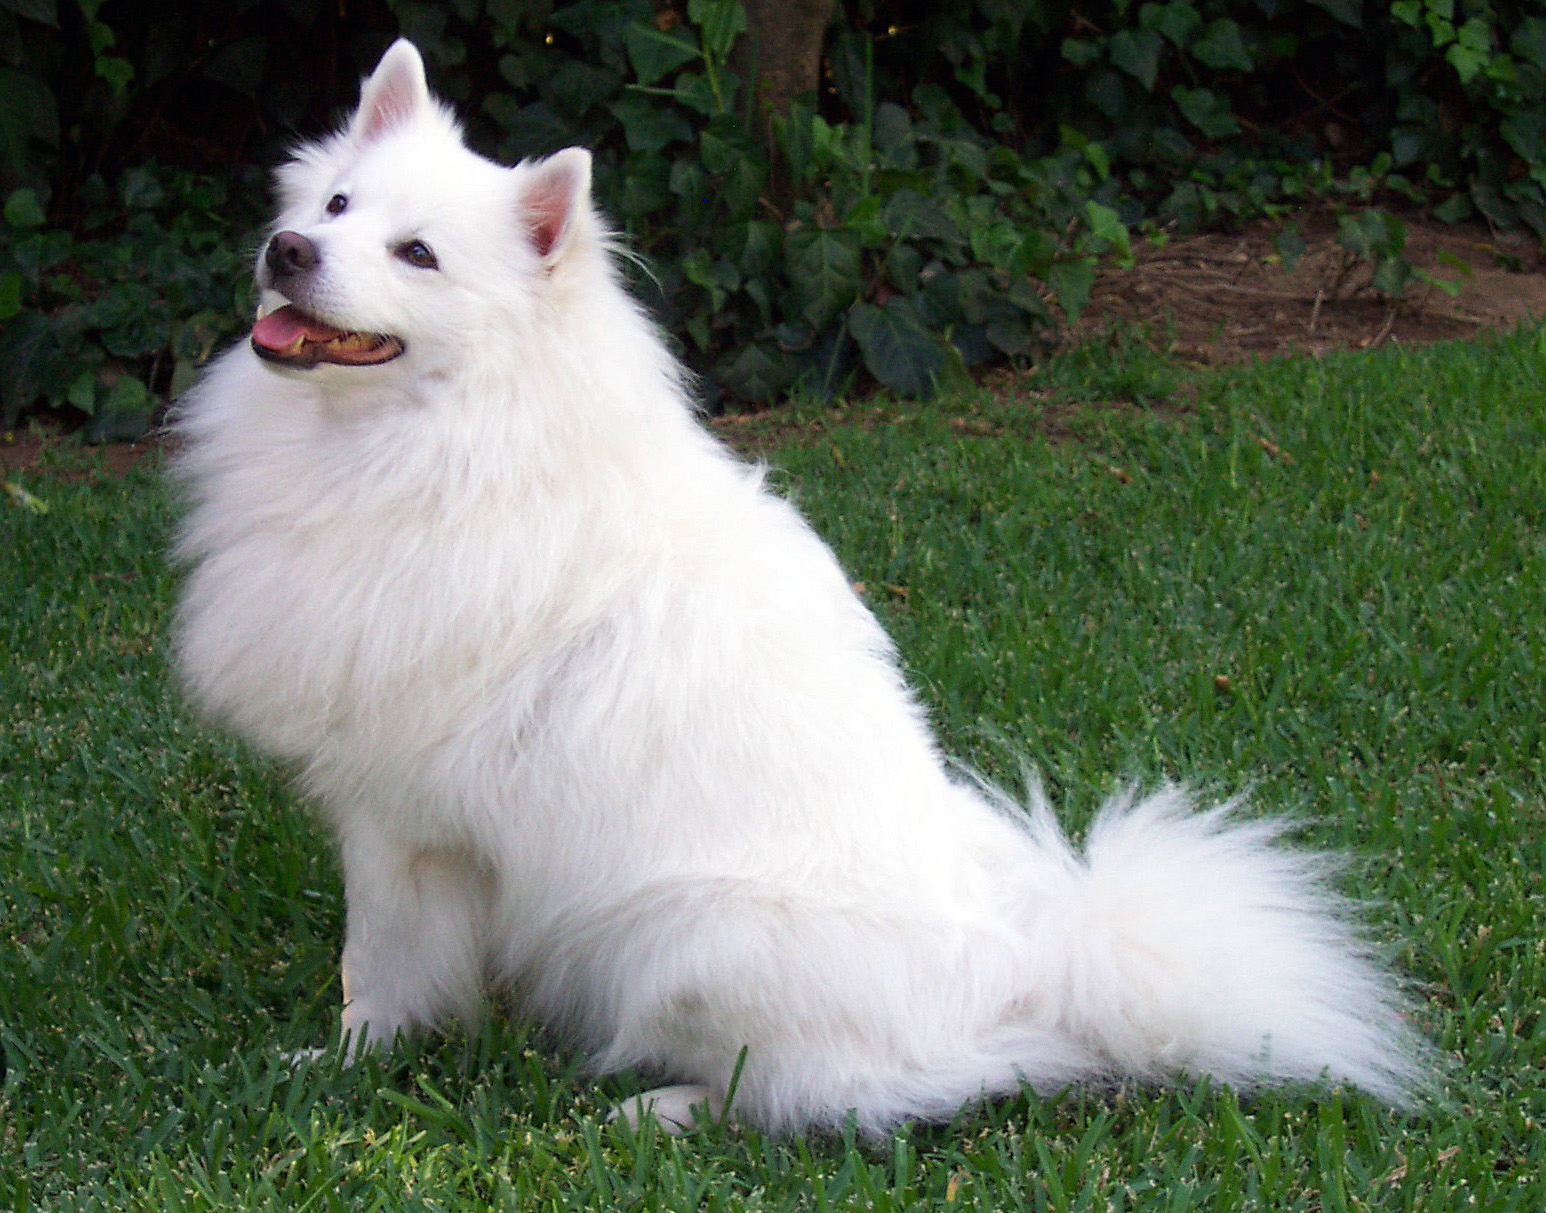

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\SSAFY/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:58<00:00, 1.75MB/s]


Top-5 예측 결과 (확률)
• 45.59%  —  Samoyed  (class id: 258)
•  3.25%  —  white wolf  (class id: 270)
•  2.80%  —  Pomeranian  (class id: 259)
•  0.93%  —  Great Pyrenees  (class id: 257)
•  0.78%  —  Eskimo dog  (class id: 248)


In [2]:
from PIL import Image
import requests, torch, torchvision.models as models
from torchvision import transforms
from torchvision.models import ResNet50_Weights   # ⬅️ 클래스 이름용 메타 데이터

# -----------------------------------------------
# 1) 샘플 이미지 다운로드 + 인라인 표시
# -----------------------------------------------
#url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
#img = Image.open(requests.get(url, stream=True).raw)
img_path = "./dog.jpg"
img = Image.open(img_path).convert("RGB")

display(img)      # VS Code 노트북에 이미지를 바로 보여줌

# -----------------------------------------------
# 2) 입력 전처리 (ImageNet 규격: 224×224, 정규화)
# -----------------------------------------------
preprocess = transforms.Compose([
    transforms.Resize(256),        # 짧은 변을 256 px로
    transforms.CenterCrop(224),    # 중앙 224×224 자르기
    transforms.ToTensor(),         # [0 … 1] 범위 텐서
    transforms.Normalize(          # ImageNet 평균·표준편차 정규화
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0).to("cuda")  # 배치 차원 추가 & GPU 업로드

# -----------------------------------------------
# 3) 사전학습 ResNet-50 모델 로드
#    weights="IMAGENET1K_V2" → ImageNet 1K 데이터로 학습된 최신 가중치
# -----------------------------------------------
model = models.resnet50(weights="IMAGENET1K_V2").to("cuda").eval()

# -----------------------------------------------
# 4) 추론 (softmax로 확률 변환)
# -----------------------------------------------
with torch.no_grad():
    logits = model(input_tensor)
probs = torch.nn.functional.softmax(logits, dim=1)[0]

# -----------------------------------------------
# 5) 클래스 이름 가져오기
#    meta["categories"]는 1000개 ImageNet 레이블이 들어 있음
# -----------------------------------------------
classnames = ResNet50_Weights.IMAGENET1K_V2.meta["categories"]

# -----------------------------------------------
# 6) 상위 5개 예측 결과를 친절하게 출력
# -----------------------------------------------
top5 = torch.topk(probs, 5)
print("Top-5 예측 결과 (확률)")

for idx, score in zip(top5.indices.cpu().numpy(), top5.values.cpu().numpy()):
    print(f"• {score*100:5.2f}%  —  {classnames[idx]}  (class id: {idx})")